В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline
from process_bank_churn import preprocess_data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier


In [2]:
raw_df = pd.read_csv('train.csv')
data = preprocess_data(raw_df, scaler_numeric=False)
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(raw_df, scaler_numeric=False)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [3]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [4]:
def predict_(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")

    return preds

In [5]:
train_preds = predict_(knn, X_train, train_targets, 'Training')
val_preds = predict_(knn, X_val, val_targets, 'Validation')

Area under ROC score on Training dataset: 0.82
Area under ROC score on Validation dataset: 0.57


Модель є перенавченою, адже на тренувальних даних AUROC  становить 82%, а на валідаційних тільки 57%

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [6]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 50)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [7]:
knn_best = knn_gs.best_estimator_
knn_best

KNeighborsClassifier(n_neighbors=np.int64(44))

In [8]:
train_preds = predict_(knn_best, X_train, train_targets, 'Training')
val_preds = predict_(knn_best, X_val, val_targets, 'Validation')

Area under ROC score on Training dataset: 0.66
Area under ROC score on Validation dataset: 0.62


Модель стала кращою адже AUROC збільшився на валідаційних даних з 57% до 62%, але у порівянянні з розрахунками з викорстання дерева прийняття рішень  вона гірше адже там при max_depth=6, max_leaf_nodes=110 AUROC на валідаційних даних був вище - 92%

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [19]:
?GridSearchCV

In [20]:
model = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}
grid_search = GridSearchCV(estimator=model,param_grid=param_grid,cv=3,scoring='roc_auc')

In [21]:
%%time
grid_search.fit(X_train, train_targets)

CPU times: user 5.78 s, sys: 5.28 ms, total: 5.79 s
Wall time: 5.84 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

In [22]:
dt_best = grid_search.best_estimator_
dt_best

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(10),
                       random_state=42)

In [23]:
train_preds = predict_(dt_best, X_train, train_targets, 'Training')
val_preds = predict_(dt_best, X_val, val_targets, 'Validation')

Area under ROC score on Training dataset: 0.90
Area under ROC score on Validation dataset: 0.90


Ця модель дає дуже гарні результати але при ручному підборі при параметрах max_depth=6, max_leaf_nodes=110 AUROC на валідаційних даних був вище - 92%.

Причиною цього є обмеження параметрів так як по max_leaf_nodes є обмеження тільки до 10

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [29]:
?RandomizedSearchCV

In [26]:
model = DecisionTreeClassifier(random_state=42)

In [27]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [28]:
%%time
random_search = RandomizedSearchCV(model, param_distributions=params_dt, n_iter=40, cv=3, scoring='roc_auc', random_state=42)

CPU times: user 39 µs, sys: 1 µs, total: 40 µs
Wall time: 43.2 µs


In [31]:
%%time
random_search.fit(X_train, train_targets)

CPU times: user 2.09 s, sys: 7.62 ms, total: 2.1 s
Wall time: 3.17 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [33]:
dt_random_search_best =  random_search.best_estimator_
dt_random_search_best

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(16),
                       max_leaf_nodes=np.int64(14), min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

In [34]:
train_preds = predict_(dt_random_search_best, X_train, train_targets, 'Training')
val_preds = predict_(dt_random_search_best, X_val, val_targets, 'Validation')

Area under ROC score on Training dataset: 0.92
Area under ROC score on Validation dataset: 0.92


Модель побудована за допомогою RandomizedSearchCV є найкращою так як AUROC на тренувальних та тестувальних даних є найвищою.

Цікаво що найкращій max_depth при RandomizedSearchCV = 16, в той час як при GridSearchCV 5. Хоча у попередньому дз при max_depth більше 6 AUROC для валідаційних даних погіршувався. Мабуть на якість моделі також впливають і інші параметри вказані у params_dt.

 Також max_leaf_nodes більший так як тут числові рамки більше за RandomizedSearchCV

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [36]:
test_raw_df = pd.read_csv('test.csv')
from process_bank_churn import preprocess_new_data
X_test = preprocess_new_data(test_raw_df, scaler, encoder, input_cols)

In [37]:
test_probs = dt_random_search_best.predict_proba(X_test)[:, 1]

In [38]:
submission_df = pd.read_csv('sample_submission.csv')
submission_df['Exited'] = test_probs
submission_df.to_csv('submission2.csv', index=False)

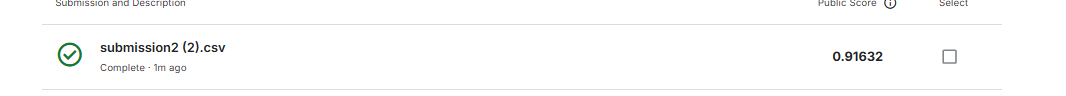